In [174]:
from CGH import *
import numpy as np
from math import factorial
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.special import hermite

In [29]:
class SLM:
    device = 'HoloEye, PLUTO-2-NIR-011'

    pixel_size = 8
    resolution = (1920, 1080)
    
    x, y = np.meshgrid(
           np.arange(-resolution[0]/2, resolution[0]/2) * pixel_size,
          -np.arange(-resolution[1]/2, resolution[1]/2) * pixel_size)

In [177]:
@dataclass
class LASER:
    wavelength: int | float
    beam_waist: int | float

    def __post_init__(self):
        self.wave_number = 2 * np.pi / self.wavelength
        self.rayleigh_range = (np.pi * self.beam_waist**2) / self.wavelength

In [192]:
class _Mode:
    def __init__(self, n: int, m: int):
        valid = all(isinstance(x, int) and x >= 0 for x in (n, m))
        if valid:
            self.n = n
            self.m = m
        else:
            raise ValueError('orders must be positive integers')
        
    def laser(self, beam: LASER):
        if isinstance(beam, LASER):
            self.beam = beam
        else:
            raise ValueError('beam must be a instance of LASER')


class HG(_Mode):
    def complex_amplitude(self, beam, x=SLM.x, y=SLM.y):
        super().laser(beam) 

        rho = x**2 + y**2
        w0 = self.beam.beam_waist
        n, m = self.n, self.m

        norm = np.sqrt(2**(1-n-m) / (np.pi * factorial(m) * factorial(n))) / w0
        hx, hy= hermite(n)(2**.5 * x / w0), hermite(m)(2**.5 * y / w0)
        amplitude = norm * hx * hy * np.exp(-rho/(w0**2))
        return amplitude


class AdvHG(_Mode):
    def __init__(self, mode1, mode2):
        valid = all(isinstance(mode, HG) for mode in (mode1, mode2))
        if valid:
            self.mode1 = mode1
            self.mode2 = mode2


    def complex_amplitude(self, beam, x=SLM.x, y=SLM.y):
        super().laser(beam)
        return (self.mode1.complex_amplitude(beam, x, y) + self.mode2.complex_amplitude(beam, x, y))**2 / np.sqrt(2)

In [206]:
def AdvHG(x, y, sigma):
    hg00 = (1/(2*np.pi*sigma**2))**(1/4) * np.exp(- (x**2 + y**2) / (4*sigma**2))
    hg01 = (1/(2*np.pi*sigma**2))**(1/4) * np.exp(- (x**2 + y**2) / (4*sigma**2)) * x/(2*sigma)
    return (hg00**2 - hg01**2) / 2

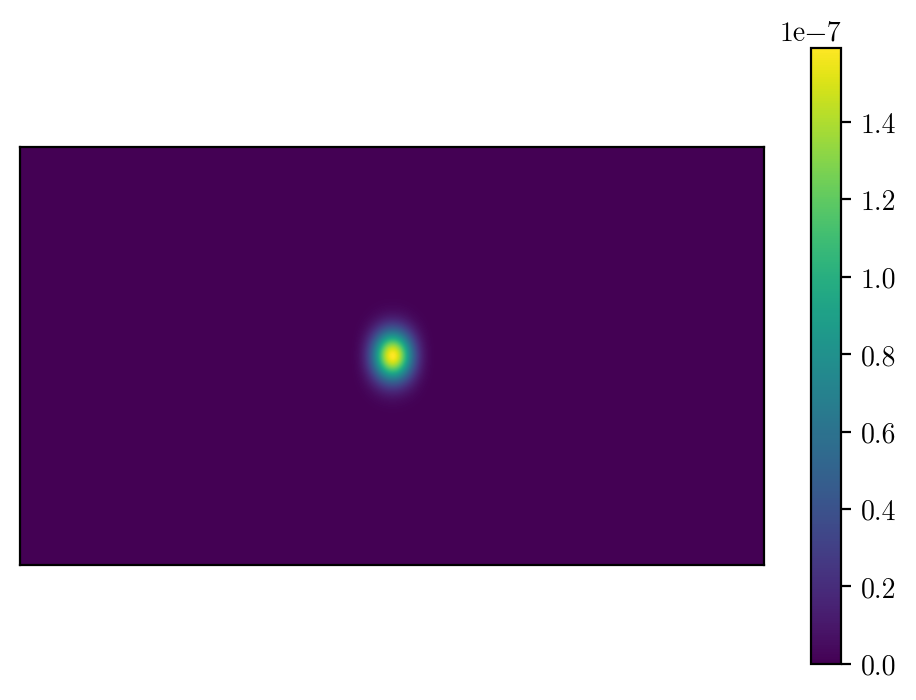

In [207]:
imshow(AdvHG(SLM.x, SLM.y, 500)**2)

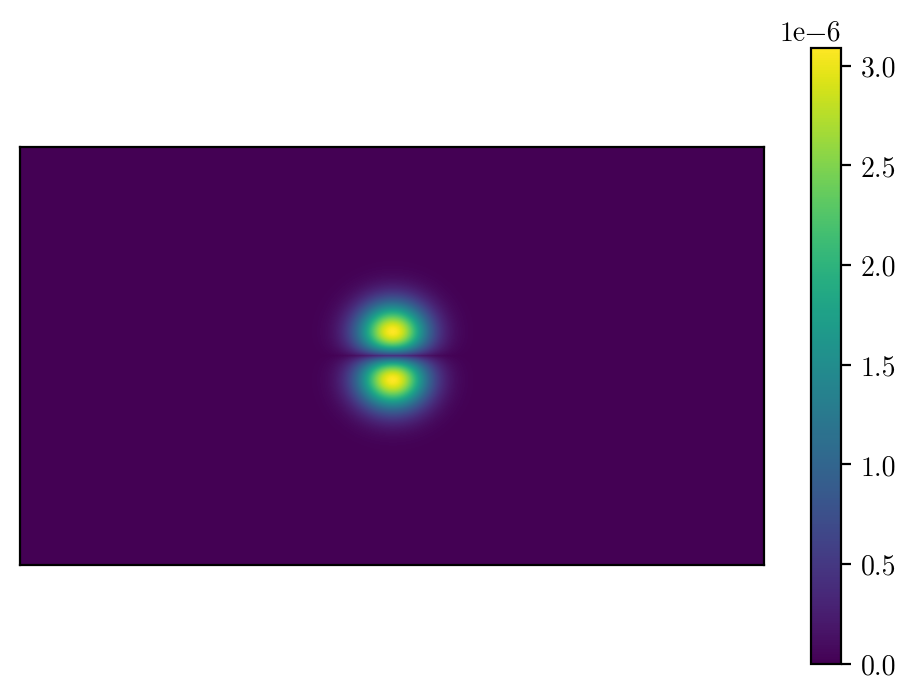

In [193]:
imshow(np.abs(AdvHG(HG(0, 0), HG(0, 1)).complex_amplitude(LASER(0.77, 1000)))**2)

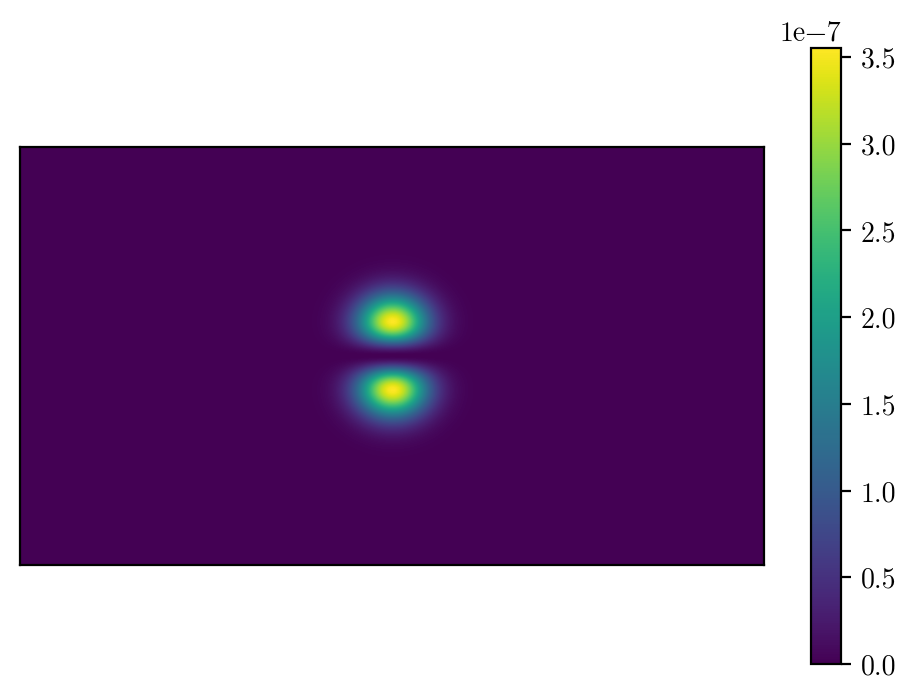

In [183]:
imshow(np.abs(HG(0, 1).complex_amplitude(LASER(0.77, 1000)))**2)

In [215]:
from myutils import *

In [216]:
a = laser(0.77, 133, hermite_gauss(0, 1)).complex_amplitude(cgh.x, cgh.y, 0.01) - laser(0.77, 133, hermite_gauss(0, 0)).complex_amplitude(cgh.x, cgh.y, 0.01)

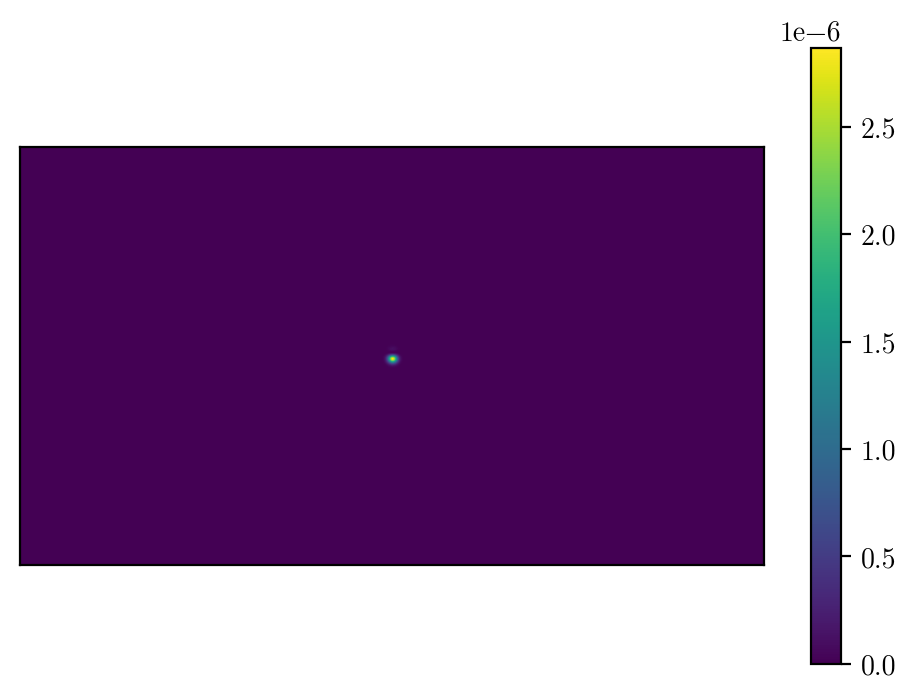

In [217]:
imshow(np.abs(a)**2)